In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import onnxruntime as ort
import numpy as np

In [8]:
# load prefill model
MODEL_DIR = "/export2/obasit/ClusterLevelServing/vllm_logs/profiler_logs/google/gemma-2-27b-it/A100_40GB/batch_controlled_runs/models_tree/prefill_model.onnx"
pre = ort.InferenceSession(MODEL_DIR)

def infer_prefill(tokens, time_since_last_batch):
    FEATURE_COLS = [
        "batch_size",
        "input_len_sum",
        "input_len_mean",
        "input_len_std",
        "tp_degree",
        "freq_mhz",
        "since_last_batch_s",
        "model"
    ]

    X = pd.DataFrame([{
        "batch_size": len(tokens),
        "input_len_sum": sum(tokens),
        "input_len_mean": float(np.mean(tokens)),
        "input_len_std": float(np.std(tokens)),
        "tp_degree": 2,  
        "freq_mhz": 1410, 
        "since_last_batch_s": float(time_since_last_batch) / 1000.0,
        "model": "gemma-2-27b-it"
    }], columns=FEATURE_COLS)


    input_feed = {}
    for col in FEATURE_COLS:
        val = X[col].values.reshape(-1, 1)
        if X[col].dtype == object or col == "model":
            input_feed[col] = val.astype(str)
        else:
            input_feed[col] = val.astype("float32")

    inputs = input_feed
    outputs = pre.run(None, inputs)
    return outputs

In [15]:
path = "/export2/obasit/ClusterLevelServing/vllm_logs/profiler_logs/google/gemma-2-27b-it/A100_40GB/batch_controlled_runs/prefill/1xTP2Prefill_1xTP2/logs_prefill_rps_sweep/prefill_0/engine_0.csv"
df_prefill = pd.read_csv(path)


df_prefill['num_prompt_tokens_reqs_evald'] = df_prefill['num_prompt_tokens_reqs'].apply(eval)

# drop empty rows first
df_prefill = df_prefill[df_prefill['num_prompt_tokens_reqs_evald'].apply(lambda x: len(x) > 0)].copy()
# then do shift of gpu times
df_prefill.loc[:, "step_with_batch_queue_time_ms"] = df_prefill["step_with_batch_queue_time_ms_1_iters_delay"].shift(-1)
df_prefill.loc[:, "since_last_batch_ms_1_iters_delay"] = df_prefill["since_last_batch_ms_1_iters_delay"].shift(-1)


token_lists = df_prefill['num_prompt_tokens_reqs_evald'].tolist()
latency_lists = (df_prefill['step_with_batch_queue_time_ms'] / 1000.0).tolist()
time_since_last_batch_lists = df_prefill['since_last_batch_ms_1_iters_delay'].tolist()

In [10]:
predicted_latencies = [infer_prefill(tokens, time_since_last_batch)[0][0][0] for tokens, time_since_last_batch in zip(token_lists, time_since_last_batch_lists)]

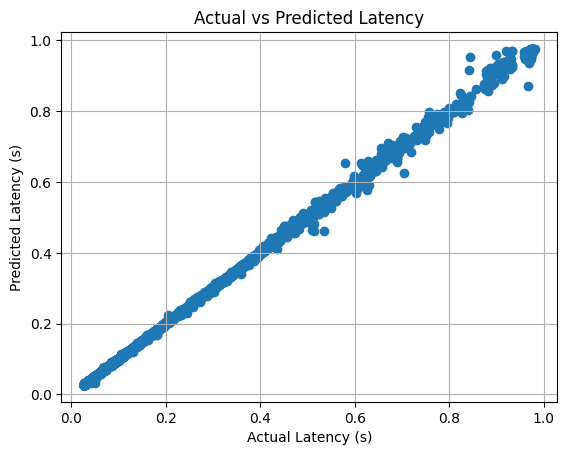

In [17]:
plt.scatter(latency_lists, predicted_latencies)
plt.xlabel("Actual Latency (s)")
plt.ylabel("Predicted Latency (s)")
plt.title("Actual vs Predicted Latency")
plt.grid(True)
plt.show()